# Modelos para el precio de combustibles. 

Se modela el precio promedio del combustible anteriormente analizado (EDA), se sigue la siguiente lógica: cuando se calculan los promedios de cada de cada combustible por separado se tiene una serie de tiempo para cada uno además se puede apreciar la correlación que cada uno presenta, de modo que un modelo predictivo es posible.



In [105]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import normalize
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
import time

In [106]:
promedios = pd.read_csv('promedios_diarios.csv')
promedios.tail(2)

,fecha,Promedio Diésel Automotríz,Promedio Premium,Promedio Regular,Promedio Diésel de Ultra Bajo Azufre (DUBA),Promedio Diésel Agrícola/Marino
364,2024-12-30,25.666764,25.392746,23.971674,25.605823,26.254286
365,2024-12-31,25.675255,25.401801,23.985676,25.618212,26.254286


<AxesSubplot:>

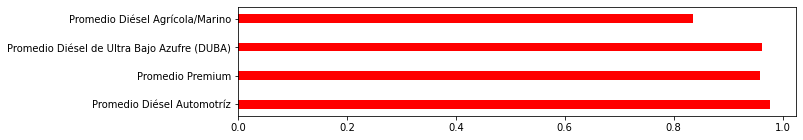

In [82]:
correlation_values = promedios.drop('fecha',axis=1).corr()['Promedio Regular'].drop('Promedio Regular')
correlation_values.plot(kind='barh', figsize=(10, 2),color='red',width=0.3)

Para pronóstico de series de tiempo se debe utilizar un método de validación cruzada distinto, debido a que para entrenar un modelo no se pueden utilizar los valores futuros de la serie. Por lo que se utilizan los valores futuros en el conjunto de prueba y los pasados para el ajuste de multiples árboles de decisión. También es importante mencionar que dentro de estos conjuntos no se elige los datos aleatoriamente. En **scikit-learn** se implementa ese requerimiento por medio de TimeSeriesSplit() que tiene como resultado varios (digamos $n$) conjuntos de índices, correspondientes a los datos que se utilizarán para el modelo. 

1. Para el primer par train-test se utilizan los primeros datos en orden cronológico
2. El segundo segmento tiene un conjunto de ajuste (train) igual al par train-test del segmento anterior.
3. El tercer train es el segundo segmento.
4. Así hasta el segmento $n$.

Lo anterior previene que los conjuntos de prueba en que el modelo no ha sido entrenado puedan ser utilizados para evaluar el modelo y siempre son una partición posterior en la serie de tiempo. Para una mejor claridad de la funcionalidad de TimeSeriesSplit() se imprime la tupla resultante.

In [125]:
y = promedios['Promedio Regular']
X = promedios.drop(['Promedio Regular'],axis=1)
dt = X.pop('fecha')
dt = pd.to_datetime(df['fecha'])

TSS = TimeSeriesSplit(n_splits=52//3)
for train, test in TSS.split(X):
    print("%s %s" % (train[:2], test[:2]))

[0 1] [26 27]
[0 1] [46 47]
[0 1] [66 67]
[0 1] [86 87]
[0 1] [106 107]
[0 1] [126 127]
[0 1] [146 147]
[0 1] [166 167]
[0 1] [186 187]
[0 1] [206 207]
[0 1] [226 227]
[0 1] [246 247]
[0 1] [266 267]
[0 1] [286 287]
[0 1] [306 307]
[0 1] [326 327]
[0 1] [346 347]


## 1. Random Forests.

MSE: 0.13684200927317014 R^2: -6.690918930913401 para el segmento 1
MSE: 0.007545528785239311 R^2: -63.659729422177506 para el segmento 2
MSE: 0.01697110866921064 R^2: -0.3843142203778407 para el segmento 3
MSE: 0.002879029254848824 R^2: 0.09860455163938409 para el segmento 4
MSE: 0.0071558051349485145 R^2: -5.165403980349246 para el segmento 5
MSE: 0.013708674025856113 R^2: -15.991605514314422 para el segmento 6
MSE: 0.020671002064161316 R^2: -15.999404181635015 para el segmento 7
MSE: 0.05658641983145898 R^2: -4.895175961204116 para el segmento 8
MSE: 0.009022591366330828 R^2: -12.932787127218576 para el segmento 9
MSE: 0.007512172311435905 R^2: -4.423703509130187 para el segmento 10
MSE: 0.003215307301981528 R^2: -5.132270126220694 para el segmento 11
MSE: 0.002433045748437815 R^2: 0.7588584656051451 para el segmento 12
MSE: 0.0010712319514381502 R^2: 0.3522472352844076 para el segmento 13
MSE: 0.0012032048885597065 R^2: 0.031345981147170576 para el segmento 14
MSE: 0.00100994349413

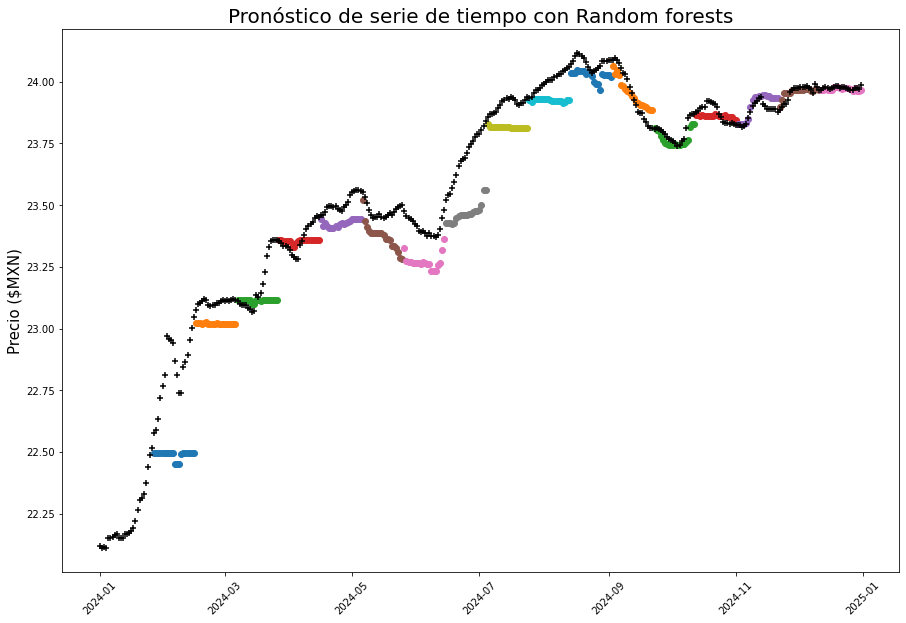

In [128]:
n_estimators=500
rf = RandomForestRegressor(max_depth=10,n_estimators=n_estimators, random_state=42)

start_time_rf = time.time()
plt.figure(figsize=(15, 10))
i=1
for train,test in TSS.split(X):
    rf.fit(X.iloc[train], y[train])
    
    y_pred_rf = rf.predict(X.iloc[test])
    
    mse_rf = mean_squared_error(y[test], y_pred_rf)
    r2_rf = r2_score(y[test], y_pred_rf)
    print(f'MSE: {mse_rf} R^2: {r2_rf} para el segmento {i}')
    i = i+1
    plt.scatter(x=dt[test],y=y_pred_rf)

plt.scatter(x=dt, y=y,color='k', marker='+')
plt.title("Pronóstico de serie de tiempo con Random forests",fontsize=20)
plt.ylabel('Precio ($MXN)',fontsize=15)
plt.xticks(rotation=45)

end_time_rf = time.time()
rf_train_time = end_time_rf - start_time_rf
print('time:',rf_train_time)


plt.show()

En la mayoría de los segmentos no se obtiene un valor cercano a $R^2 = 1$ y es un valor negativo, quiere decir que el modelo no es un mejor predictor que el promedio de los valores en el conjunto de prueba.